# MS1R1 — IL7R figure
Polygons (ms1r1-dmwm-top vs ms1r1-gm-bottom) on MERFISH spatial. DE table from Karospace. Export SVG for Inkscape.

In [19]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Polygon as MplPolygon, Patch
from matplotlib.lines import Line2D
from matplotlib import gridspec

# Publication rcParams: editable text, sans-serif, consistent sizes
mpl.rcParams.update({
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'font.family':  'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':    8,
    'axes.titlesize':  9,
    'axes.labelsize':  8,
    'axes.titleweight':'bold',
    'axes.titlepad':   4,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 7,
    'figure.dpi':      120,
    'savefig.dpi':     400,
    'savefig.bbox':    'tight',
    'axes.linewidth':  0.6,
})

H5AD = Path('/Users/chrislangseth/Downloads/GSE284005_merfish_all.companion.ready.h5ad')
POLY = Path('/Users/chrislangseth/Downloads/karospace-annotations-2026-05-04T11-01-52-851Z.json')
DE   = Path('/Users/chrislangseth/Downloads/karospace-region-de-ms1r1-dmwm-top-vs-ms1r1-gm-bottom-2026-05-04T10-48-42-241Z.csv')
OUT  = Path('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data')
OUT.mkdir(parents=True, exist_ok=True)
SAMPLE = 'ms1r1'
GENE   = 'IL7R'
POLY_LABELS = ['ms1r1-dmwm-top', 'ms1r1-gm-bottom']
POLY_SHORT  = {'ms1r1-dmwm-top': 'DMWM-top (A)', 'ms1r1-gm-bottom': 'GM-bottom (B)'}

In [20]:
with open(POLY) as f:
    polydoc = json.load(f)
polys = {p['label']: p for p in polydoc['polygons'] if p['label'] in POLY_LABELS}
for k,v in polys.items():
    print(k, 'verts=', v['n_vertices'], 'cells=', v['n_cells'], 'color=', v['color'])

ms1r1-dmwm-top verts= 459 cells= 511 color= #06d6a0
ms1r1-gm-bottom verts= 373 cells= 272 color= #118ab2


In [21]:
de = pd.read_csv(DE)
de_disp = de[['rank','gene','log2fc_a_vs_b','score','pct_expr_a','pct_expr_b']].copy()
for col in ['log2fc_a_vs_b','score','pct_expr_a','pct_expr_b']:
    de_disp[col] = de_disp[col].round(3)
de_disp

,rank,gene,log2fc_a_vs_b,score,pct_expr_a,pct_expr_b
0,1,IL7R,2.882,9.140,0.241,0.040
1,2,CXCR4,1.501,8.561,0.421,0.169
2,3,HLA-B,0.315,4.196,0.808,0.706
3,4,SERPINA3,15.057,4.130,0.037,0.000
4,5,VIM,0.287,2.825,0.642,0.537
5,6,FOXP3,2.090,1.811,0.016,0.004
6,7,LPL,10.407,1.000,0.002,0.000
7,8,EDIL3,0.047,0.070,0.025,0.026


In [22]:
adata = ad.read_h5ad(H5AD)
ad_s = adata[adata.obs['sample']==SAMPLE].copy()
xy = ad_s.obsm['spatial']
print(ad_s)
print('bbox', xy.min(0), xy.max(0))

AnnData object with n_obs × n_vars = 26082 × 500
    obs: 'nCount_Vizgen', 'nFeature_Vizgen', 'z', 'volume', 'fov', 'cell', 'sample', 'x', 'y', 'majorCluster_final', 'Region_banksy', 'Region_banksy_major'
    uns: 'X_name', 'karospace_companion'
    obsm: 'X_karo_comp', 'spatial'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'
bbox [7958.307     -45.907333] [14031.835   6808.9937]


In [23]:
gi = ad_s.var_names.get_loc(GENE)
src = ad_s.layers['counts'] if 'counts' in ad_s.layers else ad_s.X
expr = src[:, gi]
expr = np.asarray(expr.todense()).ravel() if hasattr(expr,'todense') else np.asarray(expr).ravel()
expr_log = np.log1p(expr)
print('IL7R nonzero cells:', (expr>0).sum(), '/', len(expr))
print('expr range:', expr.min(), expr.max(), 'log1p:', expr_log.min(), expr_log.max())

IL7R nonzero cells: 220 / 26082
expr range: 0.0 8.0 log1p: 0.0 2.1972245773362196


In [24]:
def poly_xy(p):
    return np.array([[v['x'], v['y']] for v in p['vertices']])

def draw_polys(ax, lw=1.5):
    for label, p in polys.items():
        verts = poly_xy(p)
        ax.add_patch(MplPolygon(verts, closed=True, fill=False,
                                edgecolor=p['color'], linewidth=lw, zorder=10))

def style_spatial(ax, dark=True):
    ax.set_facecolor('#111111' if dark else 'white')
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True if not dark else False)
        s.set_linewidth(0.4)
        s.set_edgecolor('#888888')

def add_scalebar(ax, length_um=1000, label='1 mm', color='white', pad=0.04, gap=0.04):
    """Scalebar at bottom-right; text always above the bar in display."""
    x0,x1 = ax.get_xlim(); y0,y1 = ax.get_ylim()
    xr = x1 - x0
    yr_abs = abs(y1 - y0)
    inv = y0 > y1                       # y inverted: data-down = display-up
    sign = -1 if inv else 1             # sign that points "up in display"
    x_start = x1 - pad*xr - length_um
    y_bar  = y0 + sign * pad * yr_abs   # bar above bottom edge
    y_text = y_bar + sign * gap * yr_abs  # text above bar (in display)
    ax.plot([x_start, x_start+length_um], [y_bar, y_bar],
            color=color, lw=2, solid_capstyle='butt', zorder=12)
    ax.text(x_start + length_um/2, y_text, label,
            color=color, ha='center', va='bottom',
            fontsize=6.5, fontweight='medium', zorder=12)

def polygon_legend_handles():
    return [Line2D([0],[0], color=polys[l]['color'], lw=2.2, label=POLY_SHORT[l])
            for l in POLY_LABELS if l in polys]

In [25]:
CB_PALETTE = ['#4C72B0','#DD8452','#55A467','#C44E52','#8172B3',
              '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

def cat_colors(cats, palette=None):
    palette = palette or CB_PALETTE
    return {c: palette[i % len(palette)] for i,c in enumerate(cats)}

mc_cats = list(ad_s.obs['majorCluster_final'].astype('category').cat.categories)
rb_cats = list(ad_s.obs['Region_banksy'].astype('category').cat.categories)
mc_colors = cat_colors(mc_cats)
rb_colors = cat_colors(rb_cats, palette=['#5B8FF9','#E8684A','#F6BD16','#5AD8A6','#9A7FD1'])
print('majorCluster:', mc_cats)
print('Region_banksy:', rb_cats)

majorCluster: ['Astro', 'Lym', 'Micro & Mac', 'Neuron', 'OPC', 'Oligo', 'Vascular']
Region_banksy: ['DMWM', 'GM', 'NAWM', 'Vas_Imm']


In [26]:
all_v = np.vstack([poly_xy(polys[l]) for l in POLY_LABELS])
(xmin,ymin),(xmax,ymax) = all_v.min(0), all_v.max(0)
mx = (xmax-xmin)*0.25; my = (ymax-ymin)*0.45
zoom = (xmin-mx, xmax+mx, ymin-my, ymax+my)
print('zoom bbox:', zoom)

zoom bbox: (np.float64(9202.506417749999), np.float64(11865.66039525), np.float64(164.89308559999995), np.float64(3089.1927224))


wrote /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/ms1r1_il7r_figure.svg
wrote /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/ms1r1_il7r_figure.png
wrote /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/ms1r1_il7r_figure.pdf


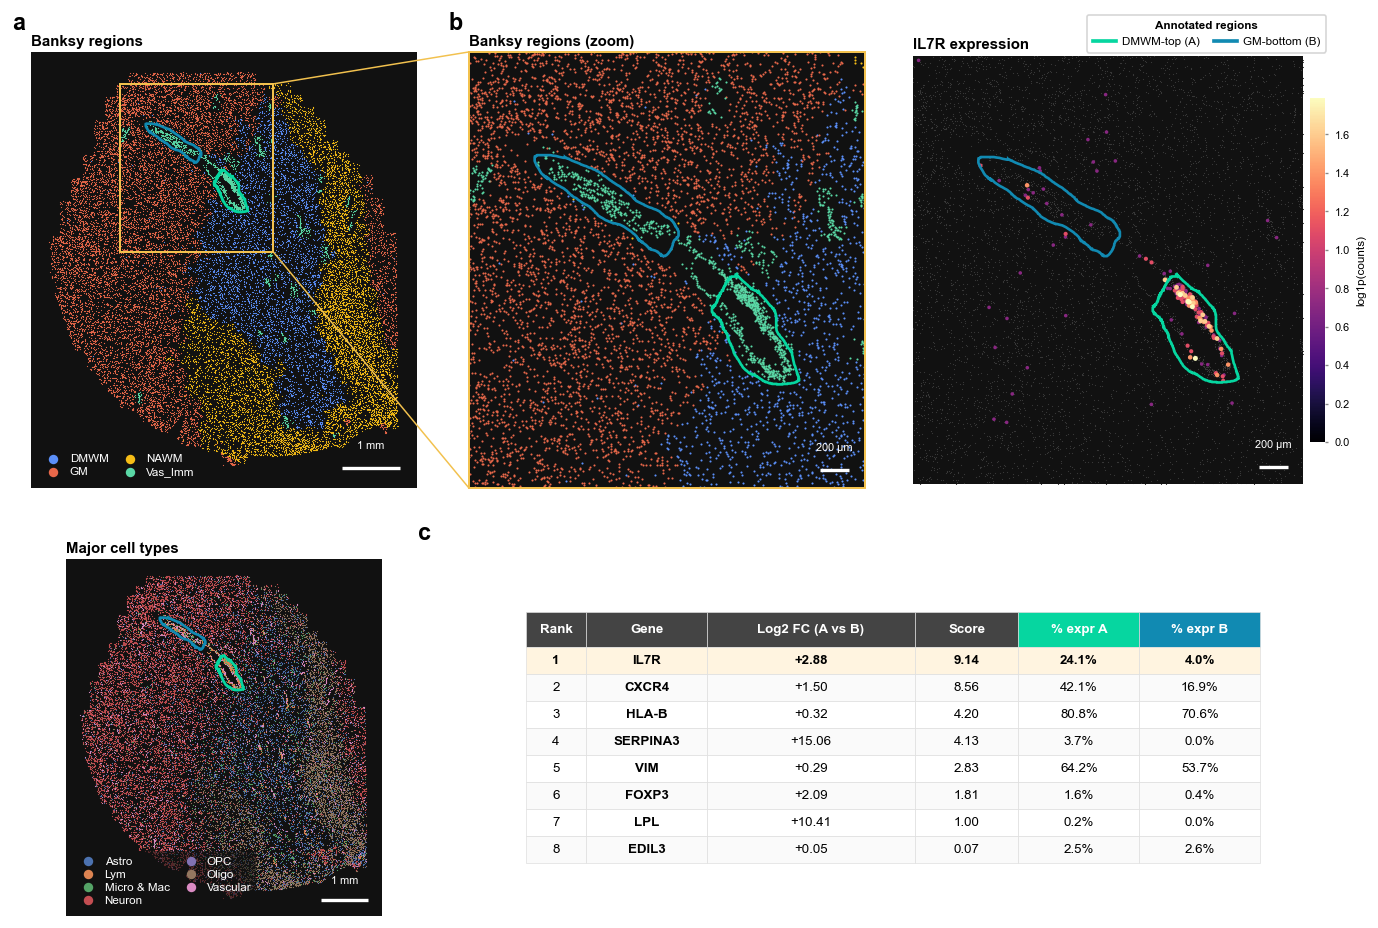

In [27]:
from matplotlib.patches import Rectangle, ConnectionPatch

fig = plt.figure(figsize=(11.5, 8.0), facecolor='white')
gs = gridspec.GridSpec(2, 3, figure=fig,
                       width_ratios=[1.0, 1.05, 1.05],
                       height_ratios=[1.0, 0.82],
                       hspace=0.18, wspace=0.10,
                       left=0.04, right=0.98, top=0.94, bottom=0.04)
axA1 = fig.add_subplot(gs[0,0])
axA2 = fig.add_subplot(gs[1,0])
axB1 = fig.add_subplot(gs[0,1])
axB2 = fig.add_subplot(gs[0,2])
axT  = fig.add_subplot(gs[1,1:])

# ---------- A1: Region_banksy (full) — source of zoom ----------
for c in rb_cats:
    m = (ad_s.obs['Region_banksy']==c).values
    axA1.scatter(xy[m,0], xy[m,1], s=0.5, c=rb_colors[c], label=c,
                 linewidths=0, rasterized=True)
draw_polys(axA1, lw=1.6)
style_spatial(axA1); axA1.invert_yaxis()
axA1.set_title('Banksy regions', loc='left')
leg1 = axA1.legend(markerscale=8, loc='lower left', ncol=2,
                   frameon=True, facecolor='#111111', edgecolor='none',
                   labelcolor='white', borderpad=0.4, handletextpad=0.4,
                   columnspacing=0.8, labelspacing=0.25)
leg1.get_frame().set_alpha(0.6)
add_scalebar(axA1)

# ---------- A2: majorCluster_final ----------
for c in mc_cats:
    m = (ad_s.obs['majorCluster_final']==c).values
    axA2.scatter(xy[m,0], xy[m,1], s=0.5, c=mc_colors[c], label=c,
                 linewidths=0, rasterized=True)
draw_polys(axA2, lw=1.6)
style_spatial(axA2); axA2.invert_yaxis()
axA2.set_title('Major cell types', loc='left')
leg2 = axA2.legend(markerscale=8, loc='lower left', ncol=2,
                   frameon=True, facecolor='#111111', edgecolor='none',
                   labelcolor='white', borderpad=0.4, handletextpad=0.4,
                   columnspacing=0.8, labelspacing=0.25)
leg2.get_frame().set_alpha(0.6)
add_scalebar(axA2)

# ---------- B1: Region_banksy zoom ----------
for c in rb_cats:
    m = (ad_s.obs['Region_banksy']==c).values
    axB1.scatter(xy[m,0], xy[m,1], s=1.6, c=rb_colors[c],
                 linewidths=0, rasterized=True)
draw_polys(axB1, lw=1.6)
style_spatial(axB1)
axB1.set_xlim(zoom[0], zoom[1]); axB1.set_ylim(zoom[3], zoom[2])
for s in axB1.spines.values():
    s.set_visible(True); s.set_edgecolor('#f2c14e'); s.set_linewidth(1.2)
axB1.set_title('Banksy regions (zoom)', loc='left')
add_scalebar(axB1, length_um=200, label='200 µm')

# ---------- B2: IL7R zoom ----------
nz = expr > 0
axB2.scatter(xy[~nz,0], xy[~nz,1], s=0.5, c='#3a3a3a', linewidths=0, rasterized=True)
vmax = float(np.quantile(expr_log[nz], 0.98)) if nz.any() else 1.0
order = np.argsort(expr_log[nz])
sizes = 2 + 7 * (expr_log[nz][order] / max(vmax,1e-9))
sc = axB2.scatter(xy[nz,0][order], xy[nz,1][order], s=sizes,
                  c=expr_log[nz][order], cmap='magma', vmin=0, vmax=vmax,
                  linewidths=0, rasterized=True)
draw_polys(axB2, lw=1.6)
style_spatial(axB2)
axB2.set_xlim(zoom[0], zoom[1]); axB2.set_ylim(zoom[3], zoom[2])
axB2.set_title(f'{GENE} expression', loc='left')
cb = fig.colorbar(sc, ax=axB2, fraction=0.038, pad=0.015, aspect=22)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=6.5, length=2, color='#888888')
cb.set_label('log1p(counts)', fontsize=7)
add_scalebar(axB2, length_um=200, label='200 µm')

# ---------- Inset indicator ----------
INSET_COLOR = '#f2c14e'
rect = Rectangle((zoom[0], zoom[2]),
                 zoom[1]-zoom[0], zoom[3]-zoom[2],
                 fill=False, edgecolor=INSET_COLOR, linewidth=1.2, zorder=11)
axA1.add_patch(rect)

for xyA, xyB in [((zoom[1], zoom[2]), (0.0, 1.0)),
                 ((zoom[1], zoom[3]), (0.0, 0.0))]:
    cp = ConnectionPatch(xyA=xyA, coordsA=axA1.transData,
                         xyB=xyB,  coordsB=axB1.transAxes,
                         color=INSET_COLOR, linewidth=0.9,
                         linestyle='-', zorder=11, clip_on=False)
    fig.add_artist(cp)

# ---------- Figure-level polygon legend ----------
poly_leg = fig.legend(handles=polygon_legend_handles(),
                      title='Annotated regions',
                      loc='upper right', bbox_to_anchor=(0.985, 0.985),
                      ncol=2, frameon=True, facecolor='white',
                      edgecolor='#cccccc', borderpad=0.5,
                      handletextpad=0.5, columnspacing=1.2)
poly_leg.get_title().set_fontweight('bold')

# ---------- DE table ----------
axT.axis('off')
de_show = de_disp.copy()
de_show.columns = ['Rank','Gene','Log2 FC (A vs B)','Score','% expr A','% expr B']
de_show['% expr A'] = (de_show['% expr A']*100).round(1).astype(str) + '%'
de_show['% expr B'] = (de_show['% expr B']*100).round(1).astype(str) + '%'
de_show['Log2 FC (A vs B)'] = de_show['Log2 FC (A vs B)'].map(lambda v: f'{v:+.2f}')
de_show['Score'] = de_show['Score'].map(lambda v: f'{v:.2f}')

cell_text = de_show.values.tolist()
table = axT.table(cellText=cell_text, colLabels=list(de_show.columns),
                  loc='center', cellLoc='center', colLoc='center',
                  colWidths=[0.07, 0.14, 0.24, 0.12, 0.14, 0.14])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.35)

A_color = polys['ms1r1-dmwm-top']['color']
B_color = polys['ms1r1-gm-bottom']['color']

for (r,c), cell in table.get_celld().items():
    cell.set_linewidth(0.4)
    cell.set_edgecolor('#dddddd')
    if r == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#444444')
        cell.set_height(0.10)
    else:
        if r % 2 == 0:
            cell.set_facecolor('#fafafa')
        if c == 1:
            cell.set_text_props(weight='bold')

table[(0,4)].set_facecolor(A_color); table[(0,4)].get_text().set_color('white')
table[(0,5)].set_facecolor(B_color); table[(0,5)].get_text().set_color('white')
table[(0,2)].set_facecolor('#444444')

for c in range(de_show.shape[1]):
    table[(1,c)].set_facecolor('#fff4e0')
    table[(1,c)].set_text_props(weight='bold')

# Panel labels a/b/c
for ax, lbl in [(axA1,'a'), (axB1,'b'), (axT,'c')]:
    ax.text(-0.05, 1.04, lbl, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='bottom', family='sans-serif')

svg_path = OUT/'ms1r1_il7r_figure.svg'
png_path = OUT/'ms1r1_il7r_figure.png'
pdf_path = OUT/'ms1r1_il7r_figure.pdf'
fig.savefig(svg_path, format='svg')
fig.savefig(png_path, dpi=400)
fig.savefig(pdf_path, format='pdf')
print('wrote', svg_path)
print('wrote', png_path)
print('wrote', pdf_path)
plt.show()

**Fig. 3.** KaroSpace bridges the researcher and the spatial data, allowing manual cell-level annotations that drive fine-grained, region-specific differential gene expression analysis. **a**, Cells colored by the original Banksy annotated regions and the corresponding Major cell types. **b**, Zoom-in of **a** and the manually drawn polygons from KaroSpace and the expression of IL7R. **c**, Output of KaroSpace on-board differential gene expression analysis identifying IL7R as a key differentially expressed gene.